## Candle Stick

### Load Data

In [ ]:
import pandas as pd

prices_dir = "../database/historical_data_yf"
stock_code = "TCS"


def load_data(stock):
    file_path = f"{prices_dir}/{stock}.NS_yf.json"
    df = pd.read_json(file_path).T
    
    dates = pd.to_datetime(df.index.tolist()).tolist()
    
    cols = df.columns.tolist()
    cols = [c.replace(f"_{stock}.NS", '').lower() for c in cols]
    df.columns = cols
    return df, dates, cols

df, dates, cols = load_data(stock_code)


print(df.tail())
print(cols)
print(dates)

                  close         high          low         open     volume
2026-04-24  2396.899902  2505.000000  2388.800049  2488.000000  5107719.0
2026-04-27  2447.600098  2459.000000  2396.899902  2396.899902  5853425.0
2026-04-28  2444.699951  2487.000000  2427.399902  2444.000000  4508363.0
2026-04-29  2474.699951  2487.899902  2447.600098  2451.000000  2835961.0
2026-04-30  2473.899902  2491.000000  2438.000000  2479.000000  3970110.0
['close', 'high', 'low', 'open', 'volume']
[Timestamp('2002-08-12 00:00:00'), Timestamp('2002-08-13 00:00:00'), Timestamp('2002-08-14 00:00:00'), Timestamp('2002-08-15 00:00:00'), Timestamp('2002-08-16 00:00:00'), Timestamp('2002-08-19 00:00:00'), Timestamp('2002-08-20 00:00:00'), Timestamp('2002-08-21 00:00:00'), Timestamp('2002-08-22 00:00:00'), Timestamp('2002-08-23 00:00:00'), Timestamp('2002-08-26 00:00:00'), Timestamp('2002-08-27 00:00:00'), Timestamp('2002-08-28 00:00:00'), Timestamp('2002-08-29 00:00:00'), Timestamp('2002-08-30 00:00:00'), Ti

### Demo Candles

In [ ]:
from utils.candles import detect_candles

last_100 = df[dates[-100]:]

candle = detect_candles(last_100)
candle.head()

# print(candle.columns.tolist())

,close,high,low,open,volume,body,range,upper_wick,lower_wick,body_ratio,...,bullish_engulfing,bearish_engulfing,bullish_engulfing_valid,bearish_engulfing_valid,piercing_line,dark_cloud_cover,morning_star,evening_star,morning_star_valid,evening_star_valid
2025-12-03,3123.223145,3154.553495,3082.955173,3083.937319,3952112.0,39.285826,71.598321,31.330350,0.982146,0.548698,...,False,False,False,False,False,False,False,False,False,False
2025-12-04,3171.544678,3191.973355,3130.490942,3136.973199,5025905.0,34.571479,61.482413,20.428677,6.482257,0.562299,...,False,False,False,False,False,False,False,False,False,False
2025-12-05,3180.384033,3213.187842,3164.866084,3172.330487,5244013.0,8.053546,48.321758,32.803809,7.464403,0.166665,...,False,False,False,False,False,False,False,False,False,False
2025-12-08,3178.714355,3201.696467,3151.312588,3185.098302,2544725.0,6.383947,50.383879,16.598165,27.401767,0.126706,...,False,False,False,False,False,False,False,False,False,False
2025-12-09,3151.018066,3175.964471,3124.401822,3172.330580,2734893.0,21.312514,51.562649,3.633891,26.616244,0.413332,...,False,False,False,False,False,False,False,False,False,False


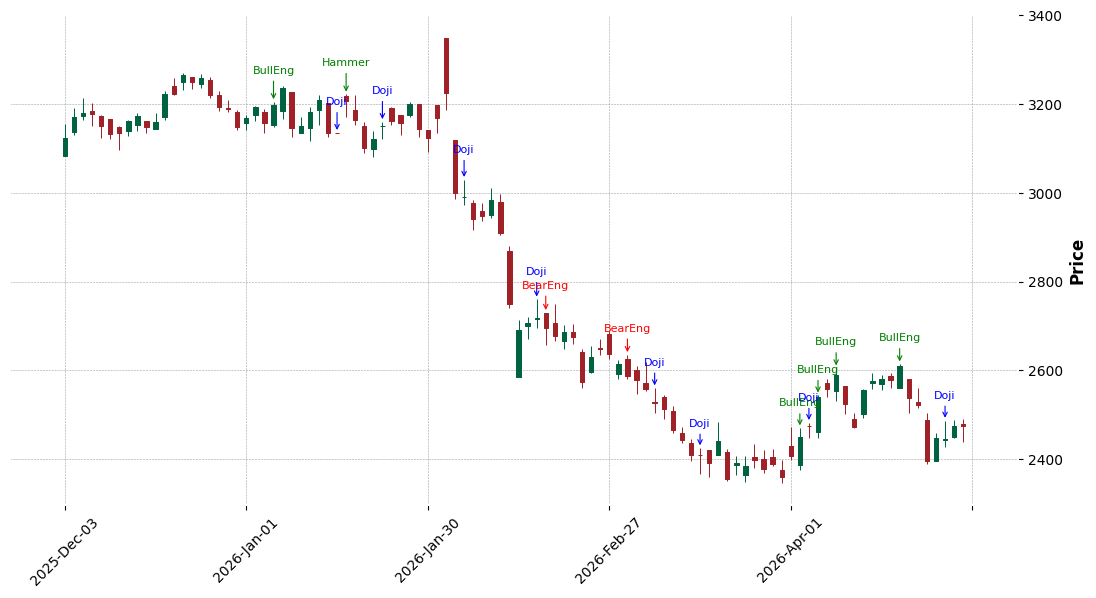

In [3]:
from utils.candles import plot_with_annotations


fig = plot_with_annotations(candle)

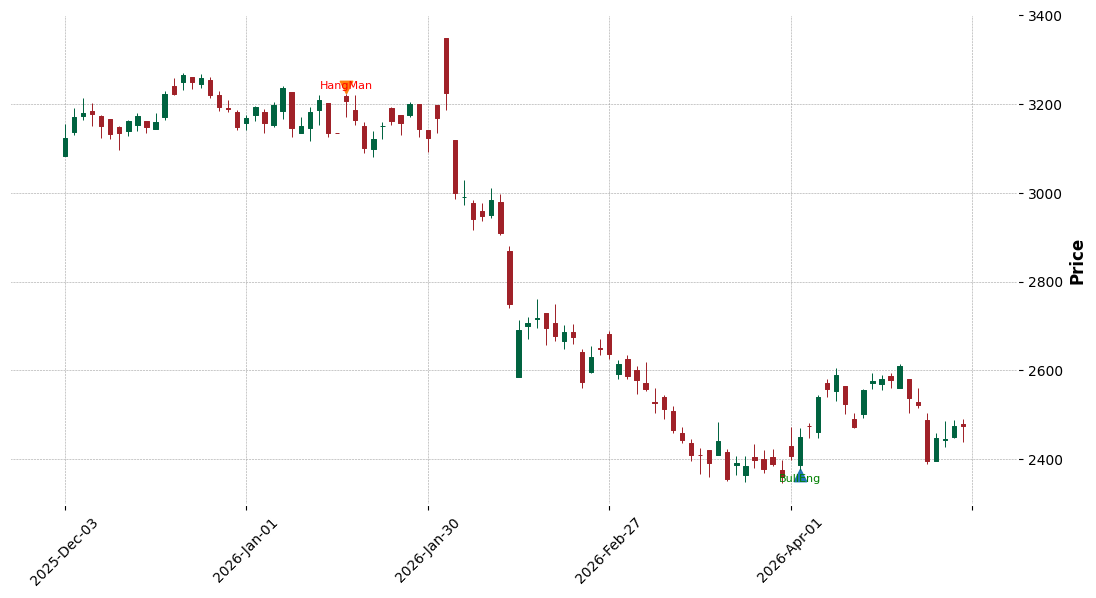

In [4]:
from utils.candles import plot_valid_signals


fig = plot_valid_signals(candle)

In [2]:
from utils.candles import detect_chart_patterns

last_100 = df[dates[-100]:]

candle = detect_chart_patterns(last_100)
candle.head()

# print(candle.columns.tolist())

,close,high,low,open,volume,swing_high,swing_low,double_top,double_bottom,head_and_shoulders,inv_head_and_shoulders,rising_wedge,falling_wedge,rounding_bottom,sym_triangle,asc_triangle,flag,rectangle,channel,cup_handle
0,3123.223145,3154.553495,3082.955173,3083.937319,3952112.0,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False
1,3171.544678,3191.973355,3130.490942,3136.973199,5025905.0,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False
2,3180.384033,3213.187842,3164.866084,3172.330487,5244013.0,3213.187842,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False
3,3178.714355,3201.696467,3151.312588,3185.098302,2544725.0,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False
4,3151.018066,3175.964471,3124.401822,3172.330580,2734893.0,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False


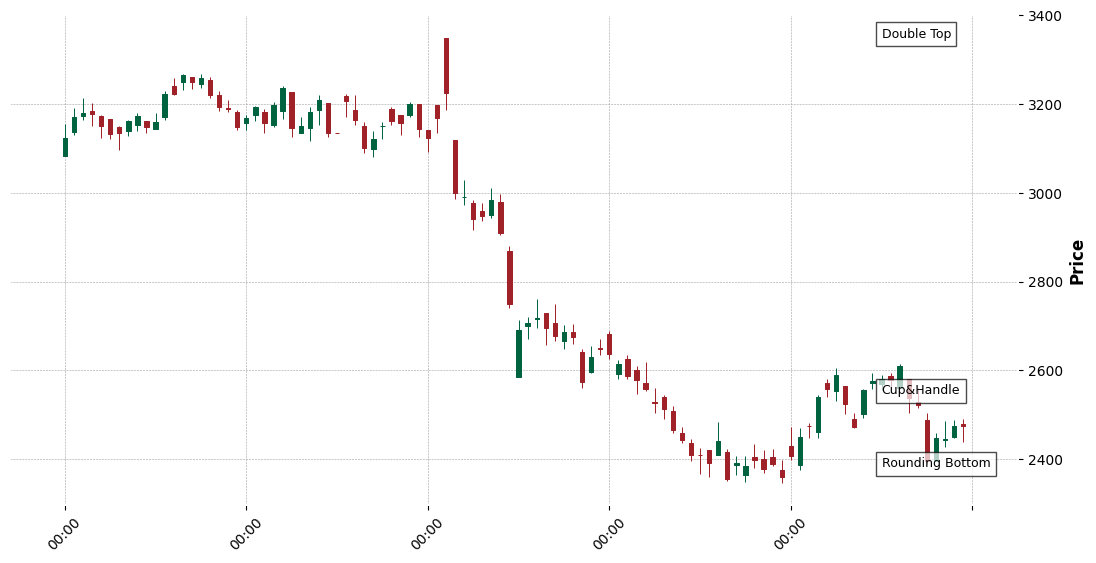

In [3]:
from utils.candles import plot_chart_patterns


fig = plot_chart_patterns(candle)

# Trial with Strong Candle Patterns

In [ ]:
import pandas as pd

prices_dir = "../database/historical_data_yf"
stock_code = "TCS"


def load_data(stock):
    file_path = f"{prices_dir}/{stock}.NS_yf.json"
    df = pd.read_json(file_path).T
    
    dates = pd.to_datetime(df.index.tolist()).tolist()
    
    cols = df.columns.tolist()
    cols = [c.replace(f"_{stock}.NS", '').lower() for c in cols]
    df.columns = cols
    return df, dates, cols

df, dates, cols = load_data(stock_code)

In [ ]:
from utils.candles import detect_candles
from utils.candles import plot_valid_signals


def analysis(lot=0, lot_size=200, log=0):
    n = len(df)

    start_date_ind = n - lot_size*(lot + 1)
    end_date_ind = n - lot_size*lot - 1

    start_date = dates[start_date_ind]
    end_date = dates[end_date_ind]

    _df = df[start_date:end_date]

    if log:
        print(start_date, end_date)
        print(_df)

    if _df.empty:
        print("⚠️ Empty dataframe. Check date slicing.")
        print(start_date, end_date)
        raise ValueError("Data slice is empty")

    candle = detect_candles(_df)
    fig = plot_valid_signals(candle)

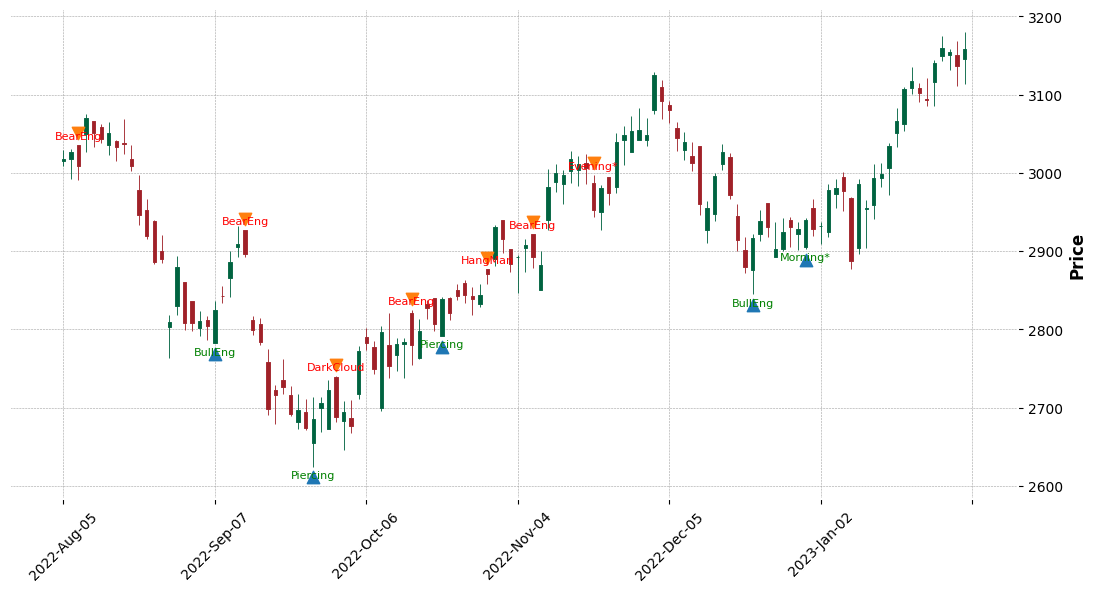

In [ ]:
lot = 4
lot_size = 200
analysis(lot, lot_size)